# PharosHLS' Case Study 1: The 2D Convolution Layer

First, we need to define the name of the folder to be created (`case_study_1_conv2d`). In this folder, all the files created below will be saved. This way, it is easy to organize different studies.

We also need to define the FPGA model to be used (`xcu250-figd2104-2L-e`). All synthesis data is always related to an FPGA model. 

In [1]:
from pharos_hls.pharos_hls import PharosHLS

pharos_hls = PharosHLS("case_study_1_conv2d")
ultrascale = "xcu250-figd2104-2L-e"

## Generating Synthesis Data

In [3]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "dim": HyperParam(name="Input Dimensions", range=(8, 50)),
    "kernel": HyperParam(name="Kernel Size", range=(2, 5), constraints=[LessThan("dim")]),
    "stride": HyperParam(name="Stride Size", range=(1, 5)),
    "padding": HyperParam(name="Padding Size", range=(0, 4), constraints=[LessThan("kernel")]),
    "ch_in": HyperParam(name="Input Channels", range=(1, 16)),
    "ch_out": HyperParam(name="Output Channels", range=(1, 16)),
    "quant": HyperParam(name="Total Quantization Bits", range=(2, 16))
}

In [ ]:
function_params = {
    "input": FunctionParam(("ch_in", "dim"), lambda ch_in, dim: (ch_in, dim, dim), input_or_output=True),
    "output": FunctionParam(("ch_out", "dim", "padding", "stride", "kernel"), lambda co, dim, p, s, k: (co, (dim - k + 2 * p) // s + 1, (dim - k + 2 * p) // s + 1), input_or_output=True),
    "weight": FunctionParam(("ch_out", "ch_in", "kernel"), lambda co, ci, k: (co, ci, k, k)),
    "bias": FunctionParam("ch_out", lambda co: co)
}

In [ ]:
pharos_hls.define_function_to_explore("Conv2d",
                                      "simple_conv_2d.h",
                                      params,
                                      function_params,
                                      ("kernel", "padding", "dim", "ch_in", "ch_out", "stride"))

In [ ]:
pharos_hls.explore_synth(frequency_MHz=100, number_of_samples=1000, part=ultrascale)

In [3]:
metric_names = {
    "BRAM_18K": "18K BRAM Usage",
    "DSP": "DSP Usage",
    "FF": "FF Usage",
    "LUT": "LUT Usage",
    "avg_total_cycles": "Avg. Total Cycles",
    "estimated_clock_period": "Est. Clock Period"
}

pharos_hls.define_metric_names(metric_names)

In [ ]:
pharos_hls.print_synth_results("Conv2d", ultrascale)

In [ ]:
df = pharos_hls.get_synth_results("Conv2d", ultrascale)

## Correlation Analysis

To obtain initial insights about the hyperparameters, we can run a correlation analysis. The default method is **Kendall's Correlation**.

We are able to obtain the raw data and to generate the heatmap chart, which will be saved in the folder `charts`, located inside the project's folder.

In [5]:
corr = pharos_hls.get_correlation_matrix("Conv2d", ultrascale)
print(corr)

        BRAM_18K   DSP    FF   LUT avg_total_cycles estimated_clock_period
ch_in        0.3  0.05  0.23  0.27              0.3                   0.16
ch_out      0.13  0.05  0.13  0.14             0.25                   0.05
dim         0.24  0.14  0.28   0.3             0.36                   0.21
kernel      0.12  0.03  0.09  0.16              0.2                   0.02
padding     0.06  0.06  0.13  0.27             0.16                  -0.01
quant       0.48  0.41  0.12  0.04            -0.01                    0.4
stride     -0.01 -0.02 -0.08  -0.1            -0.38                  -0.02


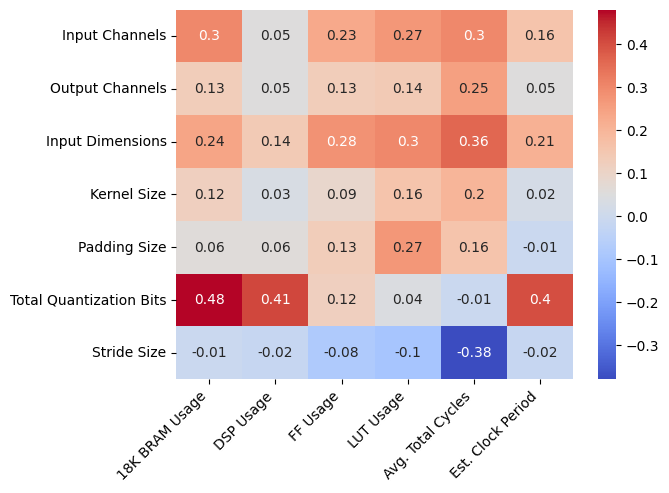

In [3]:
pharos_hls.generate_correlations_chart("Conv2d", ultrascale, chart_name="corr_conv2d.pdf")

## Aggregation Analysis

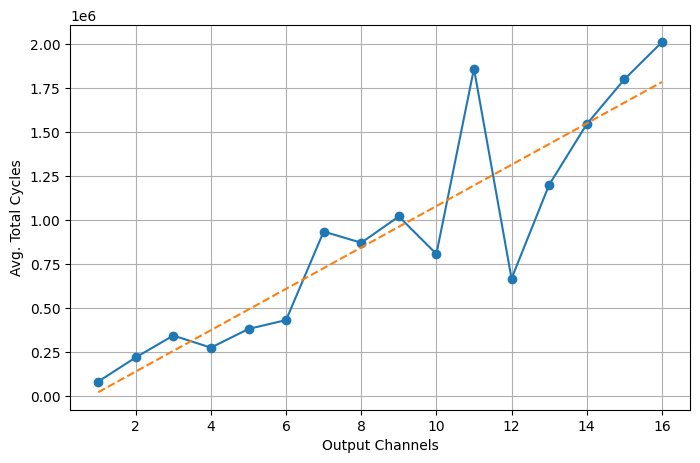

In [ ]:
pharos_hls.plot_relation("ch_out", "avg_total_cycles", "Conv2d", ultrascale, chart_name = None, regression_func = lambda x, a, b: a * x + b)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

def aux_one_to_one(ax, sub_chart_name, a, b, func, name_x, name_y):

    # média por valor de 'a'
    nova_tabela = (
        df.groupby(a)[b]
        .mean()
        .reset_index(name="media")
    )

    # ordena
    nova_tabela = nova_tabela.sort_values(a)

    # gráfico principal
    ax.plot(nova_tabela[a], nova_tabela["media"], marker="o")

    # curva ajustada (se existir)
    if func is not None:
        func_params, _ = curve_fit(
            func,
            nova_tabela[a],
            nova_tabela["media"]
        )

        x_smooth = np.linspace(
            nova_tabela[a].min(),
            nova_tabela[a].max(),
            200
        )

        y_func = func(x_smooth, *func_params)
        ax.plot(x_smooth, y_func, linestyle="--")

    # ticks inteiros no eixo X
    ax.xaxis.set_major_locator(
        ticker.MaxNLocator(integer=True, nbins=10)
    )

    # títulos e labels corretos
    ax.set_title(sub_chart_name, loc="left", fontweight="bold")
    ax.set_xlabel(name_x)
    ax.set_ylabel(name_y)

    ax.grid(True)

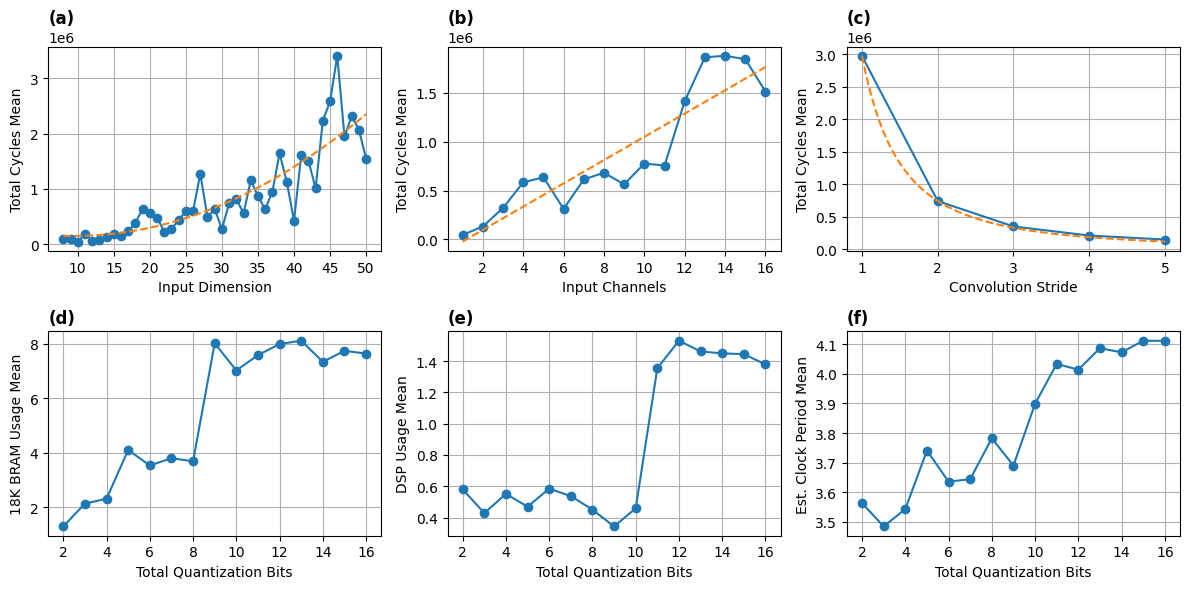

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

labels = [("(a)", "dim", "avg_total_cycles", lambda x, a, b, c: a * x * x + b * x + c, "Input Dimension", "Total Cycles Mean"), 
          ("(b)", "ch_in", "avg_total_cycles", lambda x, a, b: a * x + b, "Input Channels", "Total Cycles Mean"),
          ("(c)", "stride", "avg_total_cycles", lambda x, a: a / (x * x), "Convolution Stride", "Total Cycles Mean"),
          ("(d)", "quant", "BRAM_18K", None, "Total Quantization Bits", "18K BRAM Usage Mean"),
          ("(e)", "quant", "DSP", None, "Total Quantization Bits", "DSP Usage Mean"),
          ("(f)", "quant", "estimated_clock_period", None, "Total Quantization Bits", "Est. Clock Period Mean")]

for ax, label in zip(axes.flat, labels):
    aux_one_to_one(ax, *label)

plt.tight_layout()

plt.savefig("sbcci_images/figura_6graficos.pdf", bbox_inches="tight")
plt.show()